# Работа с NLP: токенизация и Word2Vec
Задание:  
1. Загрузить текстовый корпус (например, статьи или отзывы).  
2. Провести предобработку:  
   - Удаление стоп-слов, пунктуации.  
   - Лемматизация/стемминг.  
3. Обучить Word2Vec (Gensim).  
4. Визуализировать эмбеддинги (PCA).  

Порядок выполнения:  
1. Токенизация текста (NLTK, spaCy).  
2. Обучение Word2Vec (размерность векторов, окно контекста).  
3. Получение векторов для слов (например, "король", "женщина", "компьютер").  
4. Визуализация с помощью PCA (matplotlib).  

In [65]:
!pip3 install gensim nltk

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import nltk
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
import re


In [67]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [68]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import gensim
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [69]:
with open("/content/text.txt", "r") as file:
  content = file.read()
  content = content.replace("\n", ".")
  content = content.replace("\t", "")
  content = content.replace("–", "")
  content = re.sub(r'\d', '', content)
  corpus = content.split(".")
corpus = [i for i in corpus if len(i) > 10]
print(corpus)

[' Инструменты для разработки', 'Для разработки программного продукта были рассмотрены следующие инструменты и технологии:', 'Среда разработки IntelliJ IDEA (с плагином Android);', 'Среда разработки Android Studio;', 'Среда разработки Eclipse;', 'Язык программирования Java;', 'Язык программирования Kotlin;', 'Архитектурные шаблоны;', 'Архитектурный шаблон MVС;', 'Архитектурный шаблон MVP;', 'Архитектурный шаблон МVVМ;', 'Сервис для хостинга проектов Github', ' Среда разработки IntelliJ IDEA (с плагином Android)', 'IntelliJ IDEA  интегрированная среда разработки программного обеспечения, разработанная компанией JetBrains []', ' Данная среда разработки вместе с плагином Android предоставляет все необходимы инструменты для создания и тестирования мобильных приложений', ' IntelliJ IDEA с плагином Android поддерживает разработку на таких языках программирования как Java и Kotlin, а также предоставляет возможность интеграции с другими инструментами JetBrains', 'IntelliJ IDEA с плагином Andro

In [70]:
stop_words = set(stopwords.words('russian'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # tokenization /токенизация
    tokens = word_tokenize(text.lower(), language='russian')
    # stop word and punctuation removal/удаление стоп-слов и пунктуации
    tokens = [token for token in tokens if token not in stop_words and token not in string.punctuation]
    # lemmatization (nltk does not have full-fledged lemmatization for Russian, so it is simplified here) /
    # лемматизация (в nltk нет полноценной лемматизации для русского языка, поэтому здесь она упрощена)
    # spaCy or pymorphy2 can be used for advanced lemmatization / spaCy или pymorphy2 могут быть использованы для более продвинутой лемматизации
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return tokens

processed_corpus = [preprocess_text(doc) for doc in corpus]

In [71]:
print(processed_corpus)

[['инструменты', 'разработки'], ['разработки', 'программного', 'продукта', 'рассмотрены', 'следующие', 'инструменты', 'технологии'], ['среда', 'разработки', 'intellij', 'idea', 'плагином', 'android'], ['среда', 'разработки', 'android', 'studio'], ['среда', 'разработки', 'eclipse'], ['язык', 'программирования', 'java'], ['язык', 'программирования', 'kotlin'], ['архитектурные', 'шаблоны'], ['архитектурный', 'шаблон', 'mvс'], ['архитектурный', 'шаблон', 'mvp'], ['архитектурный', 'шаблон', 'мvvм'], ['сервис', 'хостинга', 'проектов', 'github'], ['среда', 'разработки', 'intellij', 'idea', 'плагином', 'android'], ['intellij', 'idea', 'интегрированная', 'среда', 'разработки', 'программного', 'обеспечения', 'разработанная', 'компанией', 'jetbrains'], ['данная', 'среда', 'разработки', 'вместе', 'плагином', 'android', 'предоставляет', 'необходимы', 'инструменты', 'создания', 'тестирования', 'мобильных', 'приложений'], ['intellij', 'idea', 'плагином', 'android', 'поддерживает', 'разработку', 'таки

In [72]:
w2v_model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=3,
    min_count=2,
    sg=1,
    epochs=100
    )

In [73]:
words_to_inspect = ["модель", "model"]
for word in words_to_inspect:
    if word in w2v_model.wv:
        print(f"Вектор слова '{word}':\n{w2v_model.wv[word][:10]}")  # первые 10 значений вектора
    else:
        print(f"Слово '{word}' отсутствует в модели.")

Вектор слова 'модель':
[-0.09675364  0.09891869  0.01170914  0.20215768 -0.00738622 -0.13982837
  0.06997501  0.09583295 -0.25634444 -0.08139515]
Вектор слова 'model':
[-0.06880212  0.08921464  0.0275419   0.18747361 -0.02236154 -0.12880984
  0.11549662  0.0802523  -0.28731242 -0.09728256]


In [74]:
one_word_vec = w2v_model.wv['модель']
print("\nВектор слова 'модель' (первые 5 элементов):")
print(one_word_vec[:5])
# Поиск семантически близких слов
similar_words = w2v_model.wv.most_similar('модель', topn=5)
print("\nСлова, семантически близкие к 'модель':")
for word, score in similar_words:
 print(f" {word}: {score:.3f}")


Вектор слова 'модель' (первые 5 элементов):
[-0.09675364  0.09891869  0.01170914  0.20215768 -0.00738622]

Слова, семантически близкие к 'модель':
 аналогично: 0.993
 model: 0.991
 данных: 0.989
 предоставление: 0.983
 хранение: 0.978


In [75]:
words = list(w2v_model.wv.index_to_key)
word_vectors = w2v_model.wv[words]

# Мы используем PCA для уменьшения размерности со 100 до 2
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

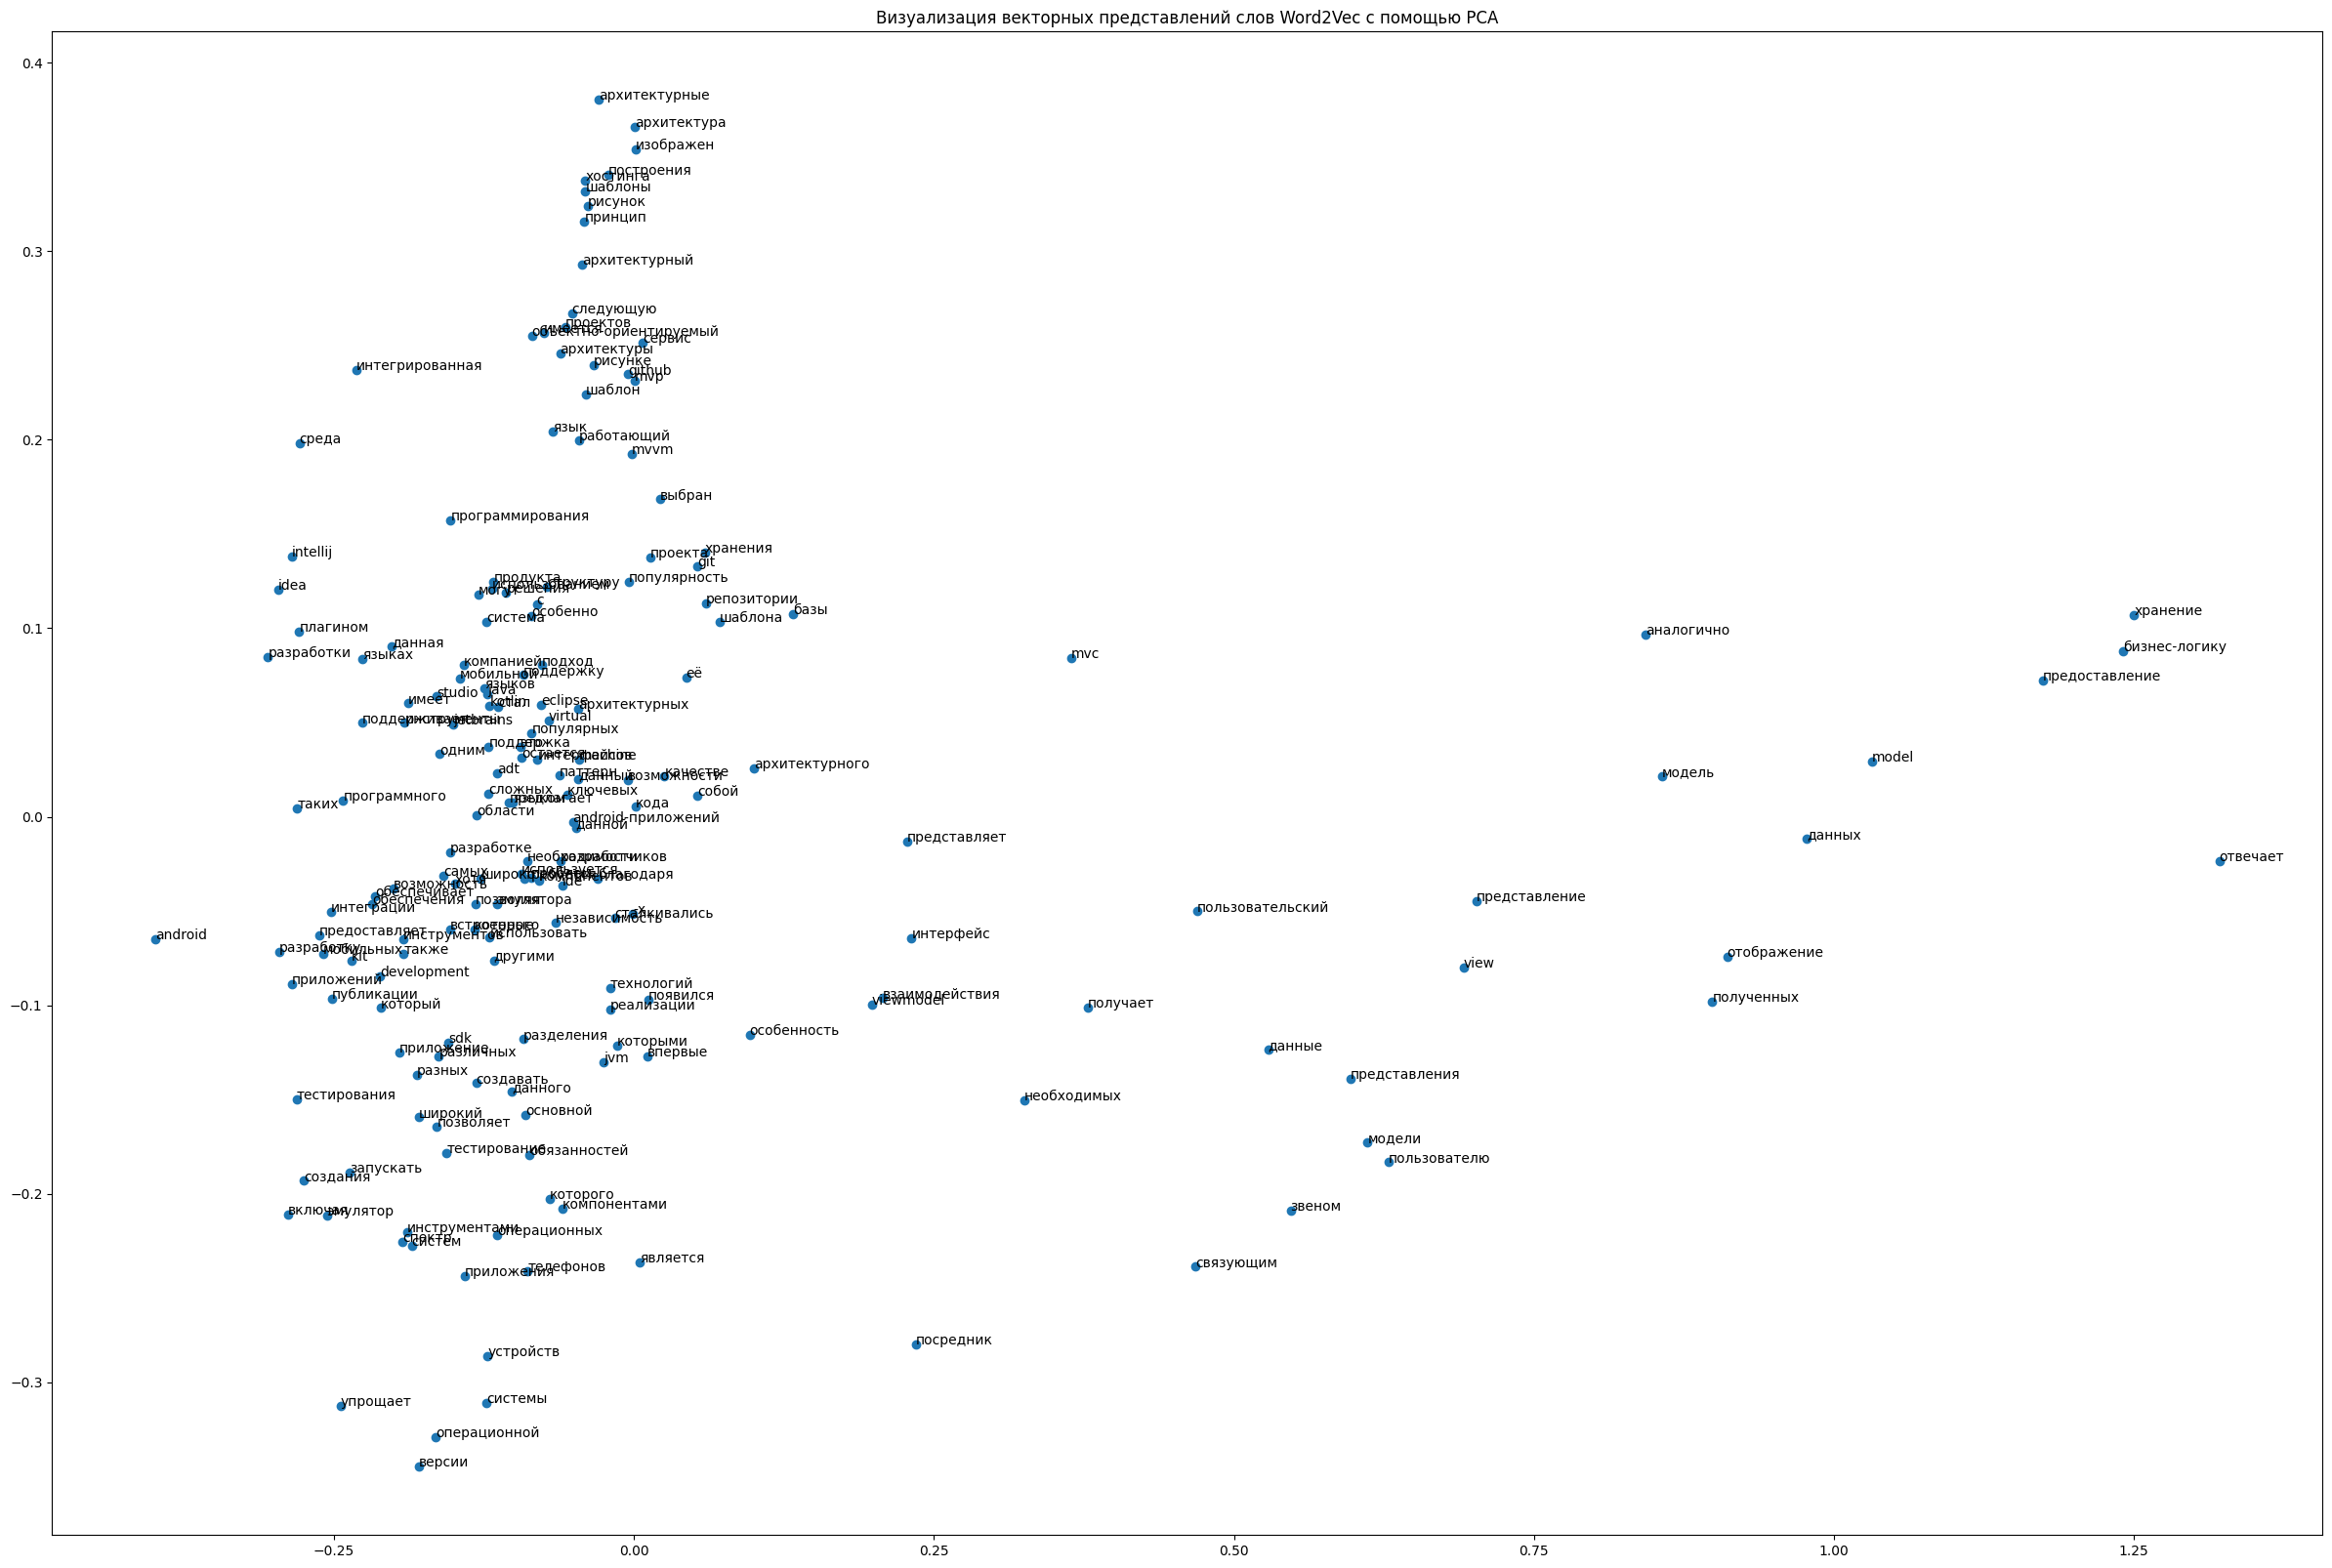

In [76]:
plt.figure(figsize=(30, 20))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Визуализация векторных представлений слов Word2Vec с помощью PCA")
plt.show()

#Доп задание 1

In [77]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import gensim
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [78]:
with open("/content/text.txt", "r") as file:
    content = file.read()
content = content.replace("\n", ".")
content = content.replace("\t", "")
content = content.replace("–", "")
content = re.sub(r'\d', '', content)
corpus = content.split(".")
corpus = [i for i in corpus if len(i) > 10]
print(corpus)

[' Инструменты для разработки', 'Для разработки программного продукта были рассмотрены следующие инструменты и технологии:', 'Среда разработки IntelliJ IDEA (с плагином Android);', 'Среда разработки Android Studio;', 'Среда разработки Eclipse;', 'Язык программирования Java;', 'Язык программирования Kotlin;', 'Архитектурные шаблоны;', 'Архитектурный шаблон MVС;', 'Архитектурный шаблон MVP;', 'Архитектурный шаблон МVVМ;', 'Сервис для хостинга проектов Github', ' Среда разработки IntelliJ IDEA (с плагином Android)', 'IntelliJ IDEA  интегрированная среда разработки программного обеспечения, разработанная компанией JetBrains []', ' Данная среда разработки вместе с плагином Android предоставляет все необходимы инструменты для создания и тестирования мобильных приложений', ' IntelliJ IDEA с плагином Android поддерживает разработку на таких языках программирования как Java и Kotlin, а также предоставляет возможность интеграции с другими инструментами JetBrains', 'IntelliJ IDEA с плагином Andro

In [79]:
stop_words = set(stopwords.words('russian'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # tokenization /токенизация
    tokens = word_tokenize(text.lower(), language='russian')
    # stop word and punctuation removal/удаление стоп-слов и пунктуации
    tokens = [token for token in tokens if token not in stop_words and token not in string.punctuation]
    # lemmatization (nltk does not have full-fledged lemmatization for Russian, so it is simplified here) /
    # лемматизация (в nltk нет полноценной лемматизации для русского языка, поэтому здесь она упрощена)
    # spaCy or pymorphy2 can be used for advanced lemmatization / spaCy или pymorphy2 могут быть использованы для более продвинутой лемматизации
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return tokens

processed_corpus = [preprocess_text(doc) for doc in corpus]

In [80]:
w2v_model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=3,
    min_count=2,
    sg=0,
    epochs=100
    )

In [81]:
words = list(w2v_model.wv.index_to_key)
word_vectors = w2v_model.wv[words]

# Мы используем PCA для уменьшения размерности со 100 до 2
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

In [82]:
words_to_inspect = ["модель", "model"]
for word in words_to_inspect:
    if word in w2v_model.wv:
        print(f"Вектор слова '{word}':\n{w2v_model.wv[word][:10]}")  # первые 10 значений вектора
    else:
        print(f"Слово '{word}' отсутствует в модели.")

Вектор слова 'модель':
[-0.12539044  0.1402848  -0.01287797  0.07311099  0.02699604 -0.30105102
  0.04712835  0.32007065 -0.18591684 -0.06579954]
Вектор слова 'model':
[-0.12289254  0.15293497 -0.00246313  0.06653974  0.02360497 -0.33736944
  0.06634335  0.35560453 -0.21136855 -0.07887202]


In [83]:
one_word_vec = w2v_model.wv['модель']
print("\nВектор слова 'модель' (первые 5 элементов):")
print(one_word_vec[:5])
# Поиск семантически близких слов
similar_words = w2v_model.wv.most_similar('модель', topn=5)
print("\nСлова, семантически близкие к 'модель':")
for word, score in similar_words:
 print(f" {word}: {score:.3f}")


Вектор слова 'модель' (первые 5 элементов):
[-0.12539044  0.1402848  -0.01287797  0.07311099  0.02699604]

Слова, семантически близкие к 'модель':
 данных: 0.998
 отвечает: 0.998
 model: 0.998
 представления: 0.998
 пользовательский: 0.998


* Вектор слова 'модель':
* [-1.7205918e-01 -2.1260935e-01  1.1171237e-01 -1.2611537e-01
  8.1885144e-02  4.2367345e-04  1.3280608e-02  1.5171924e-01
 -4.6935496e-01 -6.1110023e-02]
* Вектор слова 'model':
* [-0.16784693 -0.22008142  0.09953455 -0.10018218  0.07957771 -0.01917482
  0.03872257  0.18593375 -0.44851455 -0.04498456]

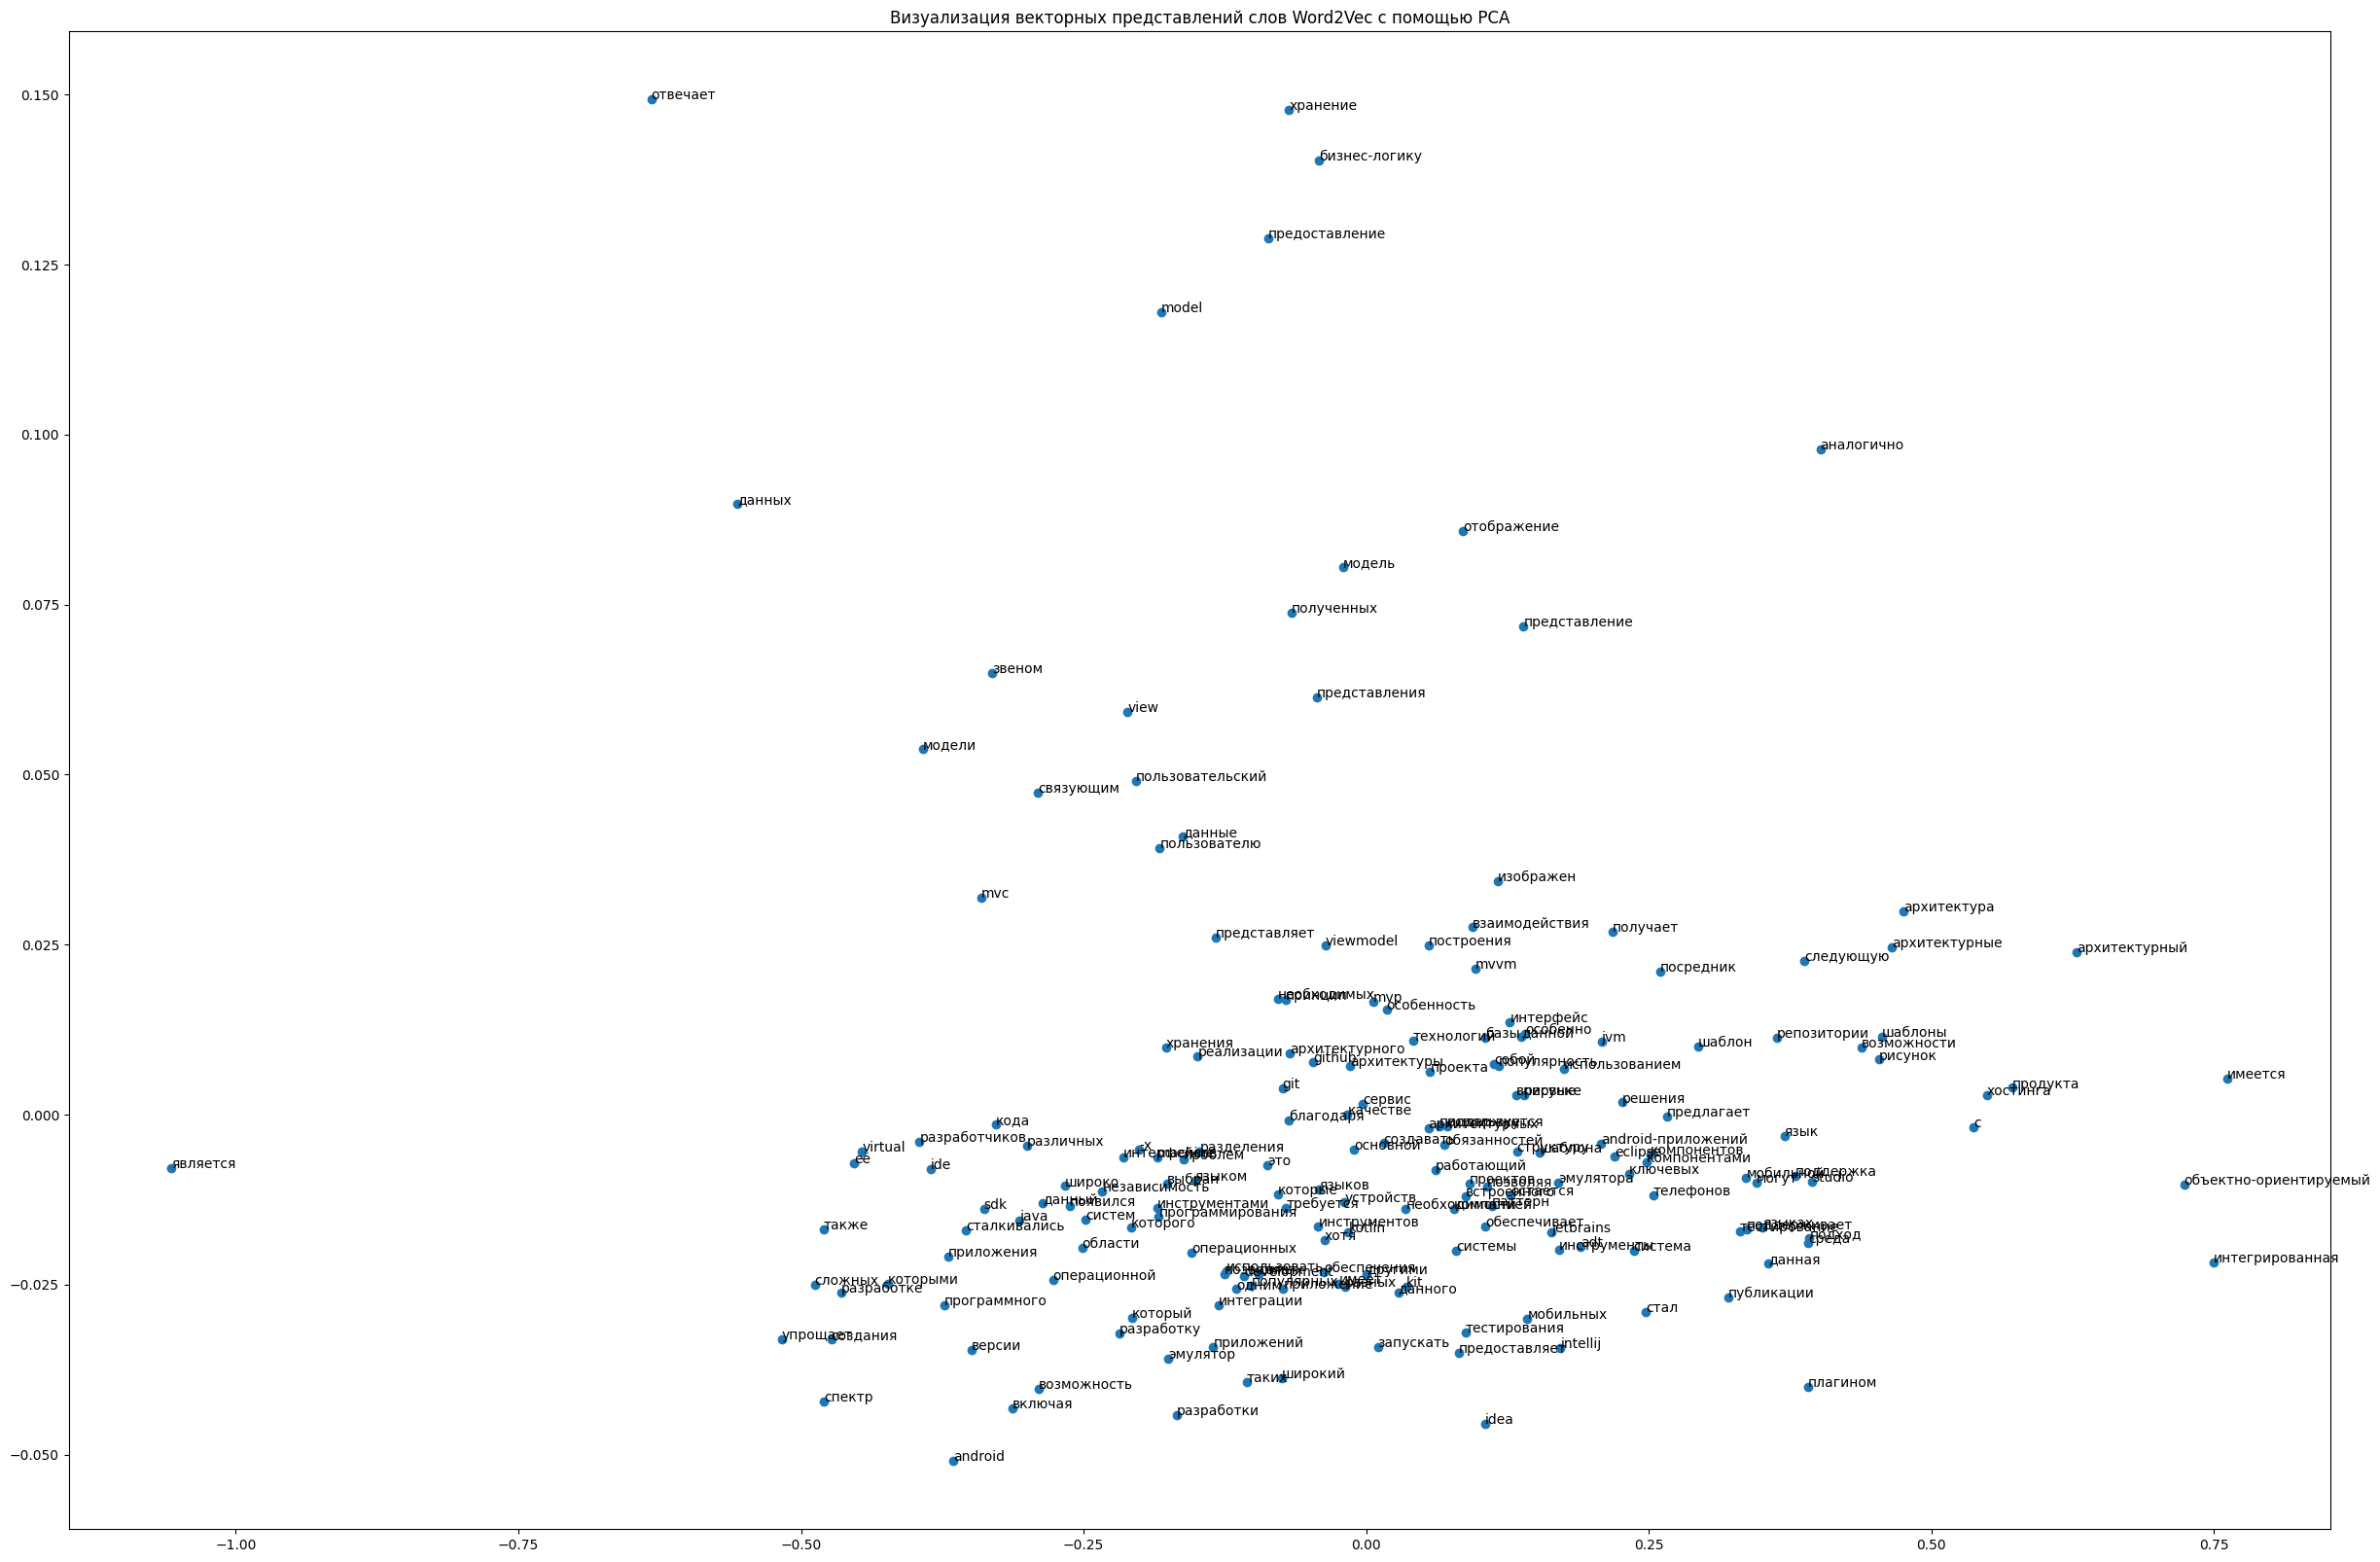

In [84]:
plt.figure(figsize=(30, 20))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Визуализация векторных представлений слов Word2Vec с помощью PCA")
plt.show()